In [1]:
# ================= CELL 1 — Imports =================

import os, copy, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix

/Users/govindapawar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
##CELL 2 — Device Setup (Mac M4 Compatible)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(seed)

print("Seed set:", seed)

Using device: mps
Seed set: 42


In [3]:
# ================= CELL 3 — Transforms(ImageNet Normalization) =================

train_transforms = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.RandomResizedCrop(300, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2)
])

val_transforms = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [4]:
# ================= CELL 4 — Datasets + DataLoaders =================


train_dataset = ImageFolder("dataset_face/train", transform=train_transforms)
val_dataset   = ImageFolder("dataset_face/val", transform=val_transforms)
test_dataset  = ImageFolder("dataset_face/test", transform=val_transforms)

class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# ================= Cell 5 — Class Weights =================

counts = Counter(train_dataset.targets)
class_counts = np.array([counts[i] for i in range(num_classes)])

weights = 1.0 / class_counts
weights = weights * (num_classes / weights.sum())

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

In [6]:
##Cell 6 — CBAM Attention

class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r, bias=False),
            nn.ReLU(),
            nn.Linear(ch//r, ch, bias=False)
        )
    def forward(self,x):
        b,c,_,_ = x.size()
        avg = F.adaptive_avg_pool2d(x,1).view(b,c)
        mx  = F.adaptive_max_pool2d(x,1).view(b,c)
        return torch.sigmoid(self.fc(avg)+self.fc(mx)).view(b,c,1,1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3)
    def forward(self,x):
        avg = torch.mean(x,1,True)
        mx,_ = torch.max(x,1,True)
        return torch.sigmoid(self.conv(torch.cat([avg,mx],1)))

class CBAM(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.ca = ChannelAttention(ch)
        self.sa = SpatialAttention()
    def forward(self,x):
        x = x*self.ca(x)
        x = x*self.sa(x)
        return x

In [7]:
# ================= Cell 7 — Model Architecture =================

# ================= CELL 7 — Model =================

class EmotionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # EfficientNet-B2 backbone
        backbone = models.efficientnet_b2(weights=None)

        # Load pretrained weights from local file
        state_dict = torch.load("efficientnet_b2.pth", map_location="cpu")
        backbone.load_state_dict(state_dict)

        self.backbone = backbone.features
        self.cbam = CBAM(1408)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(1408 * 2),
            nn.Linear(1408 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.cbam(x)

        avg = self.avg_pool(x).flatten(1)
        mx  = self.max_pool(x).flatten(1)
        x = torch.cat([avg, mx], dim=1)

        x = self.classifier(x)
        return x

    # Freeze BatchNorm during training to reduce overfitting
    def freeze_bn(self):
        for m in self.backbone.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

In [8]:
# ================= CELL 8 — Model + Loss =================

model = EmotionModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

print("Model initialized successfully")

Model initialized successfully


In [9]:
# ================= CELL 9 — Training Function =================


def train_model(model, epochs, optimizer, scheduler, best_acc=0):

    best_w = copy.deepcopy(model.state_dict())
    patience, trigger = 6, 0

    for e in range(epochs):
        print(f"\nEpoch {e+1}/{epochs}")

        # TRAIN
        model.train()
        model.freeze_bn()

        tl, correct, total = 0,0,0

        for x,y in tqdm(train_loader, leave=False):
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()

            tl += loss.item()*x.size(0)
            _,p = out.max(1)
            correct += p.eq(y).sum().item()
            total += y.size(0)

        train_acc = 100*correct/total

        # VAL
        model.eval()
        correct,total = 0,0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                _,p = out.max(1)
                correct += p.eq(y).sum().item()
                total += y.size(0)

        val_acc = 100*correct/total

        scheduler.step()

        print(f"Train Acc: {train_acc:.2f} | Val Acc: {val_acc:.2f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_w = copy.deepcopy(model.state_dict())
            torch.save({"model":best_w,"acc":best_acc},"face_model.pth")
            print("✓ Saved")
            trigger = 0
        else:
            trigger += 1

        if trigger >= patience:
            print("Early stop")
            break

    model.load_state_dict(best_w)
    return best_acc

In [10]:
# ================= Cell 10 — Phase 1: Head Training =================

for p in model.backbone.parameters():
    p.requires_grad=False

optimizer = optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

best = train_model(model, 8, optimizer, scheduler)


Epoch 1/8


Train Acc: 32.44 | Val Acc: 39.19
✓ Saved

Epoch 2/8


Train Acc: 37.58 | Val Acc: 42.47
✓ Saved

Epoch 3/8


Train Acc: 39.88 | Val Acc: 41.76

Epoch 4/8


Train Acc: 41.91 | Val Acc: 44.95
✓ Saved

Epoch 5/8


Train Acc: 43.43 | Val Acc: 44.72

Epoch 6/8


Train Acc: 45.00 | Val Acc: 46.23
✓ Saved

Epoch 7/8


Train Acc: 46.16 | Val Acc: 46.69
✓ Saved

Epoch 8/8


Train Acc: 47.10 | Val Acc: 47.18
✓ Saved


In [12]:
# ================= Cell 11 — Phase 2: Unfreeze Last 3 Blocks =================

ckpt = torch.load("face_model.pth", map_location=device)
model.load_state_dict(ckpt["model"])

# Freeze entire backbone first
for p in model.backbone.parameters():
    p.requires_grad = False

# Unfreeze last 2 blocks
for layer in list(model.backbone.children())[-2:]:
    for p in layer.parameters():
        p.requires_grad = True

# Optimizer
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=9
)

best = train_model(model, 9, optimizer, scheduler, best)


Epoch 1/9


Train Acc: 48.17 | Val Acc: 53.44
✓ Saved

Epoch 2/9


Train Acc: 54.20 | Val Acc: 57.02
✓ Saved

Epoch 3/9


Train Acc: 56.89 | Val Acc: 59.44
✓ Saved

Epoch 4/9


Train Acc: 59.93 | Val Acc: 59.88
✓ Saved

Epoch 5/9


Train Acc: 62.73 | Val Acc: 60.73
✓ Saved

Epoch 6/9


Train Acc: 64.98 | Val Acc: 61.82
✓ Saved

Epoch 7/9


Train Acc: 66.84 | Val Acc: 62.03
✓ Saved

Epoch 8/9


Train Acc: 69.18 | Val Acc: 62.20
✓ Saved

Epoch 9/9


Train Acc: 70.38 | Val Acc: 62.47
✓ Saved


In [14]:
# ================= Cell 12 — Phase 3: Full Fine-Tune =================

ckpt = torch.load("face_model.pth", map_location=device)
model.load_state_dict(ckpt["model"])

for p in model.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

best = train_model(model, 8, optimizer, scheduler, best)


Epoch 1/8


Train Acc: 69.91 | Val Acc: 63.62
✓ Saved

Epoch 2/8


Train Acc: 71.82 | Val Acc: 64.26
✓ Saved

Epoch 3/8


Train Acc: 73.49 | Val Acc: 64.46
✓ Saved

Epoch 4/8


Train Acc: 75.33 | Val Acc: 64.21

Epoch 5/8


Train Acc: 76.81 | Val Acc: 64.78
✓ Saved

Epoch 6/8


Train Acc: 77.89 | Val Acc: 65.11
✓ Saved

Epoch 7/8


Train Acc: 78.79 | Val Acc: 64.90

Epoch 8/8


Train Acc: 79.23 | Val Acc: 65.17
✓ Saved


In [16]:
# ================= CELL 13 — Save Final Model =================

ckpt = torch.load("face_model.pth", map_location=device)
model.load_state_dict(ckpt["model"])

torch.save(model.state_dict(), "face_model_final_weights.pth")

print("Final model weights saved → face_model_final_weights.pth")

Final model weights saved → face_model_final_weights.pth


Test Acc: 65.85079876886999


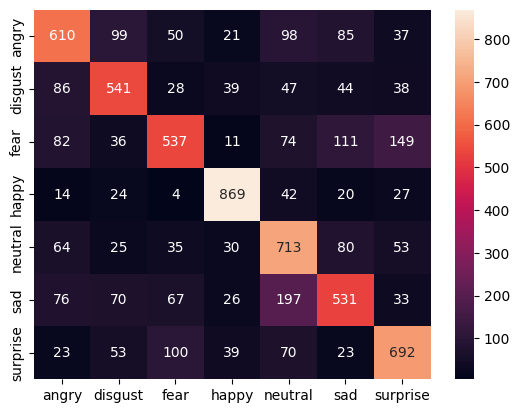

In [17]:
# ================= Cell 14 — Test Evaluation + Confusion Matrix =================

ckpt = torch.load("face_model.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

preds, labels = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        _,p = out.max(1)
        preds.extend(p.cpu().numpy())
        labels.extend(y.numpy())

acc = 100*sum(p==l for p,l in zip(preds,labels))/len(labels)
print("Test Acc:", acc)

cm = confusion_matrix(labels,preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.show()